In [90]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd
model = LinearRegression()

In [60]:
bmi = pd.read_csv("./dataset/bmi.csv")

In [61]:
bmi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 741 entries, 0 to 740
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       741 non-null    int64  
 1   Height    741 non-null    float64
 2   Weight    741 non-null    float64
 3   Bmi       741 non-null    float64
 4   BmiClass  741 non-null    object 
dtypes: float64(3), int64(1), object(1)
memory usage: 29.1+ KB


In [62]:
bmi.head()

,Age,Height,Weight,Bmi,BmiClass
0,61,1.85,109.30,31.935720,Obese Class 1
1,60,1.71,79.02,27.023700,Overweight
2,60,1.55,74.70,31.092612,Obese Class 1
3,60,1.46,35.90,16.841809,Underweight
4,60,1.58,97.10,38.896010,Obese Class 2


In [72]:
x = bmi[["Age"]]
y = bmi["Height"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = .2)
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [76]:
y_pred = model.predict(x_test)

comparison = pd.DataFrame({
    "Actual":y_test.values,
    "Prediction":y_pred
})


In [79]:
comparison.describe()

,Actual,Prediction
count,149.000000,149.000000
mean,1.700623,1.711639
std,0.087817,0.000280
min,1.470000,1.711252
25%,1.650000,1.711393
50%,1.720000,1.711581
75%,1.750000,1.711839
max,1.870000,1.712285


In [84]:
x_sorted = x_test.sort_values(by = "Bmi")

In [88]:
y_actual = y_test.loc[x_sorted.index]
y_pred = model.predict(x_sorted)

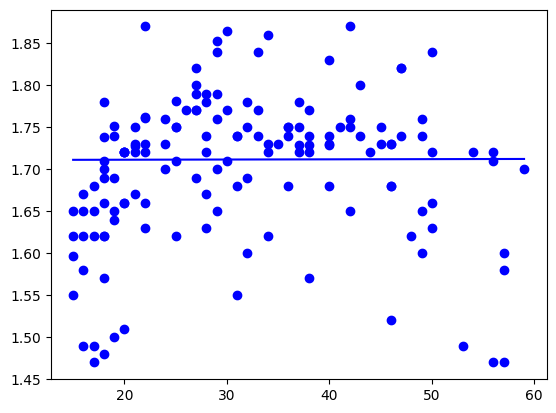

In [91]:
plt.scatter(x_sorted,y_actual,color="blue",label = "Actual Data")
plt.plot(x_sorted,y_pred,color = "blue",label="Prediction Data")

In [101]:
bmi.corr(numeric_only = True)

,Age,Height,Weight,Bmi
Age,1.000000,0.023128,0.109610,0.139157
Height,0.023128,1.000000,0.607672,0.433309
Weight,0.109610,0.607672,1.000000,0.966921
Bmi,0.139157,0.433309,0.966921,1.000000
